In [1]:
import sys
import torch
import functools
import matplotlib.pyplot as plt
import argparse, yaml, os
import torch.optim.lr_scheduler as lr_scheduler
import torchvision.transforms as transforms
import seaborn as sns
import pandas as pd
import tqdm
import glob

import tempfile, os
import numpy as np
from scipy.io import wavfile
from scipy import signal

from torch.optim import Adam
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from types import SimpleNamespace

from IPython.display import clear_output

sys.path.append('/om2/user/jmhicks/projects/TextureStreaming/code/')

from chexture_choolbox.auditorytexture.statistics_sets import (
    STAT_SET_FULL_MCDERMOTTSIMONCELLI as statistics_dict
)
from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params as model_params_tm
from texture_prior.params import statistics_set, texture_dataset
from texture_prior.utils import path

sys.path.append('../utls/')
sys.path.append('../src/model/')
sys.path.append("/om2/user/bjmedina/auditory-memory/memory/")
import DistanceMemoryModel
import encoders

from utls.loading import load_results, load_results_with_isi0_exclusion, load_results_with_isi0_dprime_exclusion, move_sequences_to_used, load_results_with_exclusion
from utls.dprime import recompute_dprime_by_isi_per_subject
from utls.reliability import compute_itemwise_split_half_reliability
from utls.plotting import plot_dprime_by_isi, plot_itemwise_split_half_scatter_df, ensure_dir


sounds_list = glob.glob("/mindhive/mcdermott/www/mturk_stimuli/bjmedina/mem_exp_atexts_2025/*wav")
device = 'cuda'
# get soem textures
pc_dims = 256

pc_texture_model = encoders.AudioTextureEncoderPCA(
    statistics_dict=statistics_set.statistics,
    pc_dims=pc_dims,
    model_params=model_params_tm,
    sr=20000,
    rms_level=0.05,
    duration=2.0,
    device=device
)

def compute_likelihood(score_model, input_stats, ckpt):
    """Computing the actual "prior" value
    If the score function can be treated as the vector field govering the temporal evolution
    of $x_t$ then we can integrate the ODE and apply a change of basis to evaluate the prior
    """
    score_model.load_state_dict(torch.load(ckpt))
    input_stats = input_stats.to(device)

    _, bpd = ode_likelihood(input_stats, score_model, marginal_prob_std_fn,
                            diffusion_coeff_fn,
                            input_stats.shape[0], device=device, eps=1e-5)
    
    return bpd

def parse(d):
  x = SimpleNamespace()
  _ = [setattr(x, k, parse(v)) if isinstance(v, dict) else setattr(x, k, v) for k, v in d.items() ]    
  return x

In [2]:
def get_dataset(batch_size, num_workers, 
                stationarity_screen_list='/om2/user/jmhicks/projects/TextureStreaming/stimuli/OVERLAPPED_0.5s_all_4s_sound_list_with_stationarity_score_no_speech_no_music_audioset_matlab_coch_rms0p02.csv', 
                audioset_path='/om/data/public/audioset/wavs/unbalanced_train_segments_downloads/', 
                duration=4):
    dataset = texture_dataset.AudioSetTextures(stationarity_screen_list, audioset_path, duration)
    #return torch.utils.data.DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=num_workers, pin_memory=True)
    return dataset

dataloader = get_dataset(16, 4)
audioset_path='/om/data/public/audioset/wavs/unbalanced_train_segments_downloads/'

In [3]:
dataloader.texture_list
unique_sounds = list(set(dataloader.texture_list.filepath.tolist()))
unique_sounds = [f"{audioset_path}{u}" for u in unique_sounds] ## TODO: CREATE NEW SOUNDS WAV FILES THAT ARE CROPPED 
## 2S SOUNDS THAT START AT THE ONSET SEPCIFIED
## THEY SHOULD BE TEMPORARY

In [4]:
# --- Settings ---
max_ranking = 2        # only keep within_sound_ranking < this
sr_target = 41000        # pc_texture_model expects 20kHz
segment_dur = 2.0        # seconds
segment_samples = int(sr_target * segment_dur)

# --- Filter the texture list ---
tex_df = dataloader.texture_list
tex_df_filt = tex_df[tex_df['within_sound_ranking'] <= max_ranking].copy()
unique_sounds = [f"{audioset_path}{u}" for u in unique_sounds]
print(f"Filtered: {len(tex_df_filt)} / {len(tex_df)} segments (within_sound_ranking < {max_ranking})")

# --- Create temp dir and extract 2s segments ---
tmp_dir = tempfile.mkdtemp(prefix="prior_2s_segments_")
tmp_paths = []
skipped = 0

for idx, row in tqdm.tqdm(tex_df_filt.iterrows(), total=len(tex_df_filt)):
    src_path = '/om/data/public/audioset/wavs/unbalanced_train_segments_downloads/' + row['filepath']
    onset = float(row['onset_time'])

    try:
        sr_orig, audio = wavfile.read(src_path)
    except Exception as e:
        print(e)
        skipped += 1
        continue

    audio = audio.astype(np.float64)

    # Extract 2s segment at original sample rate, then resample
    start_sample = int(onset * sr_orig)
    end_sample = start_sample + int(segment_dur * sr_orig)

    if end_sample > len(audio):
        skipped += 1
        continue

    segment = audio[start_sample:end_sample]

    # Save temp wav
    out_name = f"seg_{idx:06d}.wav"
    out_path = os.path.join(tmp_dir, out_name)
    wavfile.write(out_path, sr_target, segment.astype(np.int16))
    tmp_paths.append(out_path)

print(f"Created {len(tmp_paths)} temp files in {tmp_dir} (skipped {skipped})")

Filtered: 116388 / 426893 segments (within_sound_ranking < 2)


100%|██████████| 116388/116388 [08:29<00:00, 228.31it/s]

Created 116388 temp files in /tmp/prior_2s_segments_by7wb650 (skipped 0)


In [5]:
glob.glob(tmp_dir+"/*")[2]

'/tmp/prior_2s_segments_by7wb650/seg_000037.wav'

In [6]:
# parser.add_argument('--config', type=str, required=True, help='model + data configuration')
# parser.add_argument('--train', action='store_true', help='train the score-based model')
# parser.add_argument('--sample', action='store_true', help='sample from a trained model')
# parser.add_argument('--likelihood_eval', action='store_true', help='evaluate the data likelihood')
# parser.add_argument('--restart', action='store_true')
# parser.add_argument('--mode', type=str, default='textures', choices=['textures', 'mixtures'])

# sys.path.append('/om2/user/lakshmin/audio-prior/')
# from models import ScoreNetAudio, ScoreNetTexture1D, ScoreNetAudioV2
# from utils import synthesis, projection, audio
# from utils.sde_utils import *

import sys
import importlib.util
import os

# Add the new path
audio_prior_path = '/om2/user/lakshmin/audio-prior/'
sys.path.insert(0, audio_prior_path)  # insert at front of sys.path

from models import ScoreNetAudio, ScoreNetTexture1D, ScoreNetAudioV2
from utils import synthesis, projection, audio
from utils.sde_utils import *

config = "/om2/user/bjmedina/auditory-memory/memory/assets/bryan.yaml"
train = False
sample = False
likelihood_eval = True
restart = False
mode = 'textures'

device = 'cuda'

In [7]:
df = yaml.safe_load(open(config))
cfg = parse(df)

print(cfg)

pt_file = torch.load('/om2/user/lakshmin/audio-prior/assets/texture_statistics_4096texturePCs.pt')

namespace(train=namespace(n_epochs=512, batch_size=4096, lr=0.0001), data=namespace(data_root='/om2/user/lakshmin/audio-prior/assets/texture_statistics_4096texturePCs.pt', data_mix_root='/om2/user/lakshmin/audio-prior/assets/mixture_statistics_4096PCs.pt', n_pcs=256, var_scale=False), model=namespace(ckpt_path='ckpts/texture_diffusion2D_prior_{}pcs_mode_{}.pth', use_single_dim_conv=False, embed_dim=256, channels=[32, 64, 128], kernel_size=5, dilations=[1, 2, 4, 8, 16]), sample=namespace(sample_batch_size=4096, num_steps=2500))


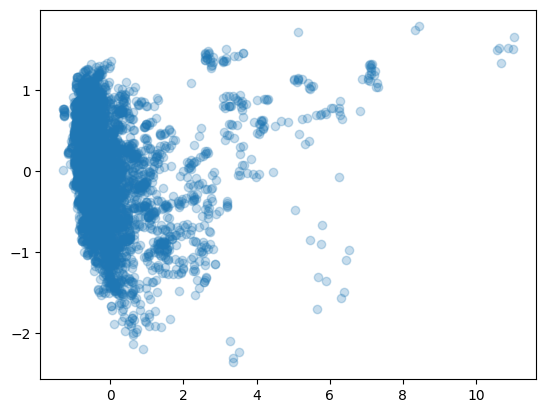

In [8]:
pt_file.shape
num_sounds = 5000
plt.scatter(pt_file[:num_sounds,0], pt_file[:num_sounds,1], alpha=0.25)

In [9]:
score_model = torch.nn.DataParallel(
                    ScoreNetAudioV2(
                        marginal_prob_std=marginal_prob_std_fn, 
                        channels=cfg.model.channels, 
                        embed_dim=cfg.model.embed_dim
                        )
                    )

score_model = score_model.to(device)

ckpt_path = cfg.model.ckpt_path.format(cfg.data.n_pcs, mode)
ckpt_path = "/om2/user/lakshmin/audio-prior/" + ckpt_path
if 'SLURM_RESTART_COUNT' in os.environ.keys() or restart:
    score_model.load_state_dict(torch.load(ckpt_path))

print(ckpt_path)

/om2/user/lakshmin/audio-prior/ckpts/texture_diffusion2D_prior_256pcs_mode_textures.pth


In [10]:
from dataloader import TextureStatsDataset
texture_dataset = TextureStatsDataset(
                config=cfg,                        
                device=device
            )

print(texture_dataset)

sounds_to_test = 1000
effective_num_sounds = sounds_to_test

rep = []

t_something = 0.01

exp_sounds = unique_sounds

for sound in glob.glob(tmp_dir+"/*")[:sounds_to_test]:
    vec = pc_texture_model(sound)

    try:
        if not torch.is_tensor(vec):
            vec = torch.tensor(vec)  # convert if it's a numpy array
        rep.append(vec)

        t = torch.tensor([t_something], device=vec.device).float()

        

        score = score_model(vec.view(1, 1, 1, 256), t)

        # 2. Flatten for norm computation per sample
        score_flat = score.view(score.size(0), -1)  # [B, 256]
        
        # 3. Normalize: divide by norm per sample
        norms = score_flat.norm(p=2, dim=1, keepdim=True) + 1e-8  # prevent division by zero
        unit_score_flat = score_flat / norms  # [B, 256]

        #print(unit_score_flat)
        
        # 4. Reshape back to original format
        unit_score = unit_score_flat.view_as(score)  # [B, 1, 1, 256]

        #input()
        #clear_output(wait=True)

    
    except Exception as e:
        print(e)
        effective_num_sounds -= 1


# Now stack all into one tensor
x = torch.stack(rep).float()  # shape: [N, ...]
x = x.view(len(rep), 1, 1, 256)

bpd_textures = compute_likelihood(score_model, input_stats=x, ckpt=ckpt_path)

x_numpy = x.squeeze(1).squeeze(1).detach().cpu().numpy()


In [11]:
x_orig = x_numpy
idx = np.random.random_integers(0, x_orig.shape[0]-1, cfg.sample.sample_batch_size)
x_orig = x_orig[idx]

/tmp/ipykernel_1026362/2645570267.py:2: DeprecationWarning: This function is deprecated. Please call randint(0, 999 + 1) instead
  idx = np.random.random_integers(0, x_orig.shape[0]-1, cfg.sample.sample_batch_size)


In [12]:
sample_batch_size = cfg.sample.sample_batch_size
sampler = Euler_Maruyama_sampler_1d if cfg.model.use_single_dim_conv else Euler_Maruyama_sampler
init_dims = [1, cfg.data.n_pcs] if cfg.model.use_single_dim_conv else [1, 1, cfg.data.n_pcs]

print(sample_batch_size*2)

# generate samples using the specified sampler.
samples, trajectory = sampler(
                        score_model,
                        marginal_prob_std_fn,
                        diffusion_coeff_fn,
                        num_steps=cfg.sample.num_steps,
                        batch_size=sample_batch_size*10,
                        device=device,
                        init_dims=init_dims)

samples = samples.squeeze().detach().cpu().numpy()

8192


 13%|█▎        | 332/2500 [01:49<11:52,  3.04it/s]
/om2/user/lakshmin/audio-prior/utils/sde_utils.py:10: SyntaxWarning: invalid escape sequence '\s'
  """Compute the mean and standard deviation of $p_{0t}(x(t) | x(0))$.
/om2/user/lakshmin/audio-prior/utils/sde_utils.py:24: SyntaxWarning: invalid escape sequence '\s'
  """Compute the diffusion coefficient of our SDE.


OutOfMemoryError: CUDA out of memory. Tried to allocate 1.25 GiB. GPU 

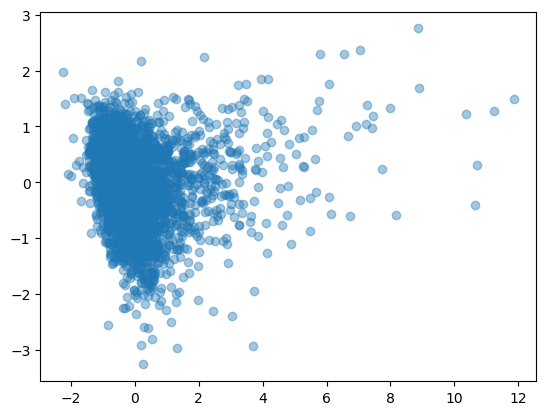

In [24]:
plt.scatter(samples[:,0], samples[:,1], alpha=0.4)

In [25]:
len(trajectory)

2501

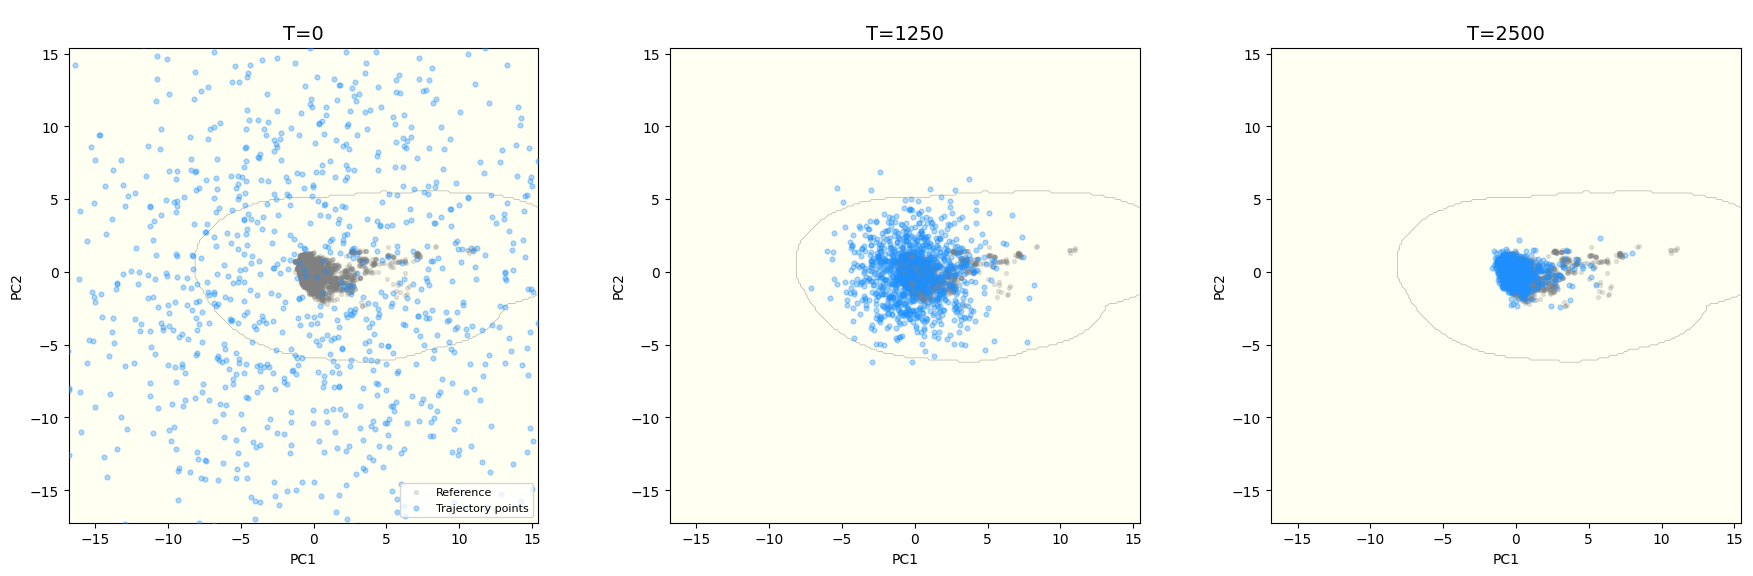

T=2501, N=4096, D=256, showing 1000 trajectories at t=[0, 1250, 2500]


In [26]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# traj_np already has shape (T, N, D) = (2501, 4096, 256)
# If rebuilding:
traj_np = np.stack([
    (tr.detach().cpu().numpy() if hasattr(tr, "detach") else np.asarray(tr)).squeeze(1).squeeze(1)
    for tr in trajectory
])  # (T, N, D)

traj_np.shape

T, N, D = traj_np.shape
traj_2d = traj_np[:, :, :2]   # (T, N, 2)
Z_train = pt_file[:5000, :2]

# pick timesteps from T axis
t_check = [0, T // 2, T - 1]

# subset trajectories from N axis
rng = np.random.default_rng(
)
n_show = min(1000, N)
n_idx = rng.choice(N, size=n_show, replace=False)

# bounds from train + shown trajectory points at selected timesteps
sel_pts = traj_2d[t_check][:, n_idx, :].reshape(-1, 2)
all_pts = np.vstack([Z_train, sel_pts])
x_min, x_max = np.percentile(all_pts[:, 0], [0.5, 99.5])
y_min, y_max = np.percentile(all_pts[:, 1], [0.5, 99.5])

# KDE background on train data
G0, G1 = np.meshgrid(np.linspace(x_min, x_max, 220), np.linspace(y_min, y_max, 220))
Q = gaussian_kde(Z_train.T, bw_method=0.15)(np.vstack([G0.ravel(), G1.ravel()])).reshape(G0.shape)

fig, axes = plt.subplots(1, len(t_check), figsize=(18, 5.5), constrained_layout=True)
extent = [x_min, x_max, y_min, y_max]

for ax, t in zip(axes, t_check):
    ax.imshow(Q, origin="lower", cmap="YlOrRd", alpha=0.25, extent=extent, aspect="equal")
    ax.contour(G0, G1, Q, levels=8, colors="k", linewidths=0.5, alpha=0.3)

    ax.scatter(Z_train[:, 0], Z_train[:, 1], c="gray", s=8, alpha=0.2, label="Reference", zorder=2)
    ax.scatter(traj_2d[t, n_idx, 0], traj_2d[t, n_idx, 1],
               c="dodgerblue", s=12, alpha=0.35, label="Trajectory points", zorder=4)

    ax.set_title(f"T={t}", fontsize=14)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle(" ", fontsize=18, y=1.02)
plt.show()

print(f"T={T}, N={N}, D={D}, showing {n_show} trajectories at t={t_check}")


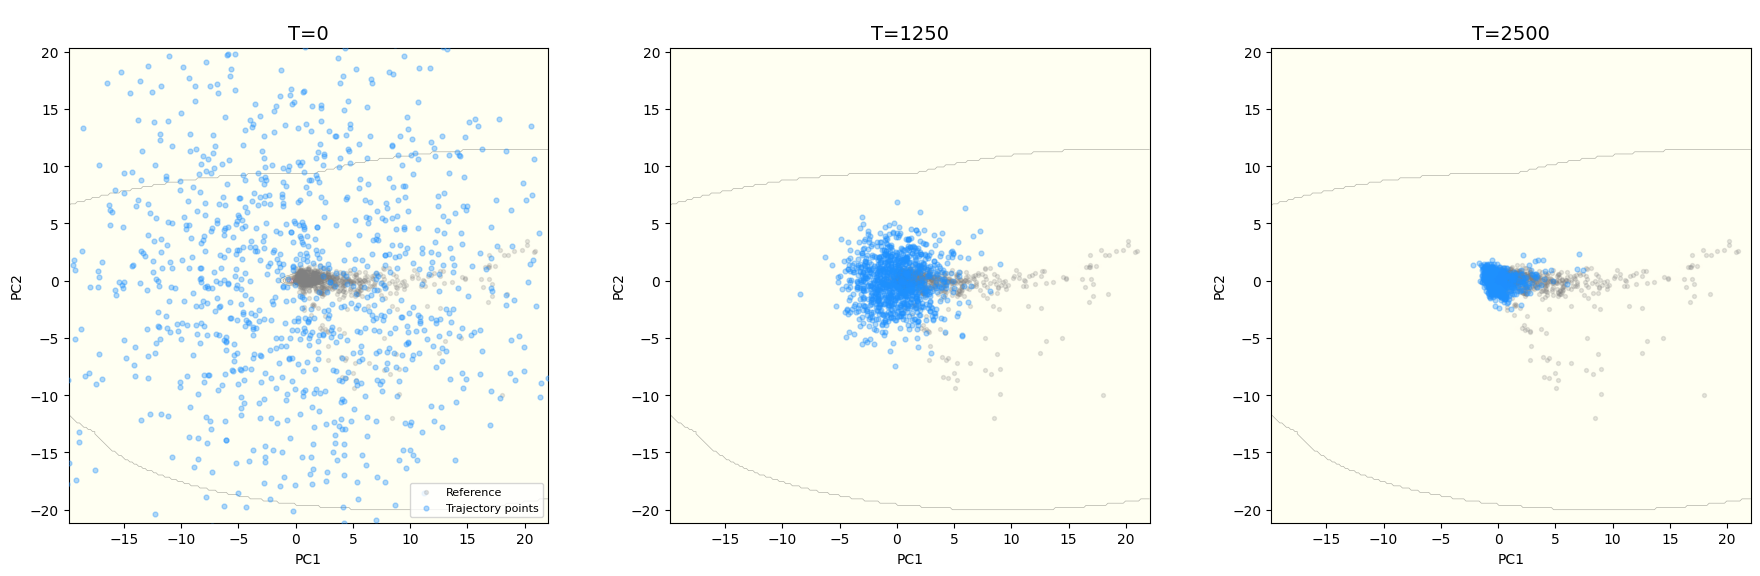

T=2501, N=4096, D=256, showing 1000 trajectories at t=[0, 1250, 2500]


In [27]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# traj_np already has shape (T, N, D) = (2501, 4096, 256)
# If rebuilding:
traj_np = np.stack([
    (tr.detach().cpu().numpy() if hasattr(tr, "detach") else np.asarray(tr)).squeeze(1).squeeze(1)
    for tr in trajectory
])  # (T, N, D)

traj_np.shape

T, N, D = traj_np.shape
traj_2d = traj_np[:, :, :2]   # (T, N, 2)
Z_train = x_numpy[:, :2]

# pick timesteps from T axis
t_check = [0, T // 2, T - 1]

# subset trajectories from N axis
rng = np.random.default_rng(
)
n_show = min(1000, N)
n_idx = rng.choice(N, size=n_show, replace=False)

# bounds from train + shown trajectory points at selected timesteps
sel_pts = traj_2d[t_check][:, n_idx, :].reshape(-1, 2)
all_pts = np.vstack([Z_train, sel_pts])
x_min, x_max = np.percentile(all_pts[:, 0], [0.5, 99.5])
y_min, y_max = np.percentile(all_pts[:, 1], [0.5, 99.5])

# KDE background on train data
G0, G1 = np.meshgrid(np.linspace(x_min, x_max, 220), np.linspace(y_min, y_max, 220))
Q = gaussian_kde(Z_train.T, bw_method=0.15)(np.vstack([G0.ravel(), G1.ravel()])).reshape(G0.shape)

fig, axes = plt.subplots(1, len(t_check), figsize=(18, 5.5), constrained_layout=True)
extent = [x_min, x_max, y_min, y_max]

for ax, t in zip(axes, t_check):
    ax.imshow(Q, origin="lower", cmap="YlOrRd", alpha=0.25, extent=extent, aspect="equal")
    ax.contour(G0, G1, Q, levels=8, colors="k", linewidths=0.5, alpha=0.3)

    ax.scatter(Z_train[:, 0], Z_train[:, 1], c="gray", s=8, alpha=0.2, label="Reference", zorder=2)
    ax.scatter(traj_2d[t, n_idx, 0], traj_2d[t, n_idx, 1],
               c="dodgerblue", s=12, alpha=0.35, label="Trajectory points", zorder=4)

    ax.set_title(f"T={t}", fontsize=14)
    ax.set_xlabel("PC1")
    ax.set_ylabel("PC2")
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)

axes[0].legend(loc="lower right", fontsize=8)
plt.suptitle(" ", fontsize=18, y=1.02)
plt.show()

print(f"T={T}, N={N}, D={D}, showing {n_show} trajectories at t={t_check}")
